# 🌱 Crop Image Classifier: Alfalfa vs Garbanzo

Now we are going to train our own small image classifier!

The model will look at a crop photo and predict one of two labels:

- **alfalfa**
- **garbanzo**

We are using a technique called **transfer learning**. That means we start with a model that already learned useful image features from lots of images, then teach it our two crop classes.

This notebook is designed to be low-code. You can run each cell from top to bottom.

## 🧠 Big idea

A neural network learns from examples.

For this project, each example is:

> image → crop label

The model sees many labeled images and practices guessing the right label. After training, we test it on new photos it has not seen before.

## 1. Import the tools

In [62]:
# This cell gathers all the "tools" we need, like getting your gear ready before
# working in the field. Each "import" line borrows a toolbox someone else already built.

from pathlib import Path   # helps us point to files and folders on the computer
import json                # lets us save and read small text files (like a notes file)
import os                  # helps us talk to the computer's file system

import numpy as np                 # a fast calculator for big lists of numbers
import matplotlib.pyplot as plt    # draws pictures and charts so we can see results

import tensorflow as tf            # the main "brain-building" toolkit
from tensorflow import keras       # a friendlier, simpler way to use TensorFlow
from tensorflow.keras import layers  # the building blocks we stack to make the brain

# Print the version so we know the toolkit loaded correctly.
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Choose simple settings

Smaller images and fewer epochs train faster, which is useful in Binder.

You can tweak `BATCH_SIZE`, `LEARNING_RATE`, and `EPOCHS` in the settings cell below.

If training is too slow, set `EPOCHS = 2` or skip training and load a saved model.

In [63]:
# Here we write down where things live and pick a few settings.
# Think of this like labeling your bins and deciding how you'll work before you start.

DATA_DIR = Path("data/crop_images")   # the folder that holds our crop photos
MODEL_DIR = Path("models")            # the folder where we'll keep the trained "brain"
MODEL_DIR.mkdir(exist_ok=True)        # make that folder if it doesn't exist yet

# Where we'll save the finished model and the list of crop names it can recognize.
MODEL_PATH = MODEL_DIR / "crop_classifier_mobilenetv2.keras"
CLASS_NAMES_PATH = MODEL_DIR / "class_names.json"

IMG_SIZE = (160, 160)   # shrink every photo to 160x160 dots so they're all the same size

# Hyperparameters: these are the "knobs" you can turn to change how training goes.
BATCH_SIZE = 32        # how many photos the model looks at together before learning a bit
LEARNING_RATE = 0.001  # how big each learning "step" is (too big = sloppy, too small = slow)
EPOCHS = 50             # how many times the model studies the whole photo collection
SEED = 42              # a fixed "shuffle number" so results stay the same each run

# Our photos are split into three groups, each in its own folder:
TRAIN_DIR = DATA_DIR / "train"  # photos used to teach the model
VAL_DIR = DATA_DIR / "val"      # photos used to check progress while learning
TEST_DIR = DATA_DIR / "test"    # photos saved for the final exam at the end

print("Training folder:", TRAIN_DIR)
print("Validation folder:", VAL_DIR)
print("Test folder:", TEST_DIR)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Epochs:", EPOCHS)

Training folder: data/crop_images/train
Validation folder: data/crop_images/val
Test folder: data/crop_images/test
Batch size: 32
Learning rate: 0.001
Epochs: 50


## 3. Load the crop images

The preprocessing script already resized and organized the images into folders.

Keras reads the folder names as class labels.

In [64]:
# This cell loads our photos from the folders and gets them ready for the model.

# First, a safety check: if the training folder is missing, stop and remind us
# to run the data-prep script that fills it with photos.
if not TRAIN_DIR.exists():
    raise FileNotFoundError(
        f"Could not find {TRAIN_DIR}. Run scripts/prepare_crop_dataset.py first."
    )

# Load the teaching photos. Keras automatically uses each folder's name as the crop label.
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,    # resize every photo to our chosen size
    batch_size=BATCH_SIZE,  # group them into small batches
    seed=SEED,              # shuffle the same way every time
)

# Load the "check progress" photos the same way.
val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

# Grab the list of crop names (the folder names) and show them.
class_names = train_ds.class_names
print("Class names:", class_names)

# Save that list to a file so we can reuse it later without re-loading the photos.
with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names, f)

Found 220 files belonging to 2 classes.
Found 46 files belonging to 2 classes.
Class names: ['alfalfa', 'garbanzo']


## 4. Look at a few training images

Before training, always inspect your data.

Ask yourself:

- Do the labels look right?
- Are the images clear?
- Are there weird backgrounds or duplicates?
- Could the model cheat by looking at something unrelated to the crop?

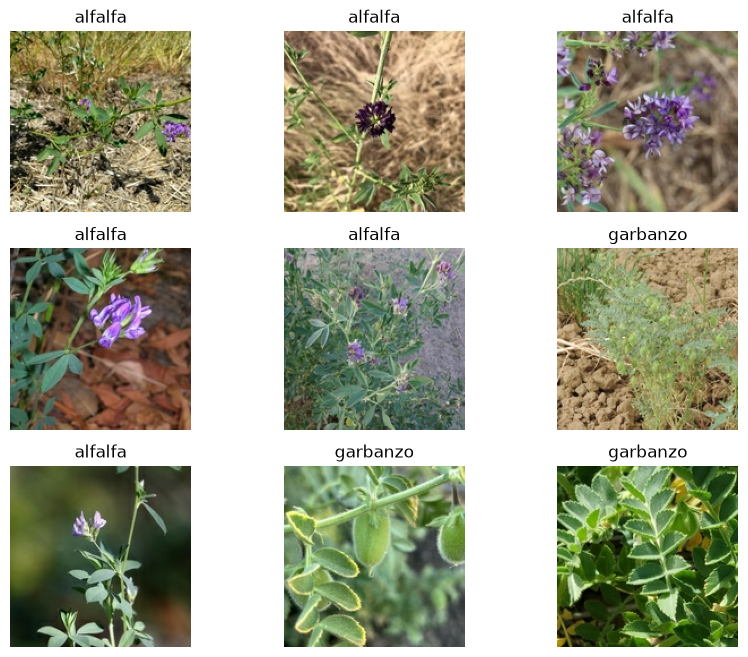

In [65]:
# Let's peek at a few photos so we can see what the model will study.
# This draws a 3x3 grid (up to 9 photos) with each crop's name on top.

plt.figure(figsize=(10, 8))           # set the size of the picture we're drawing
for images, labels in train_ds.take(1):   # grab one batch of photos
    for i in range(min(9, len(images))):   # loop through up to 9 of them
        ax = plt.subplot(3, 3, i + 1)      # pick a spot in the 3x3 grid
        plt.imshow(images[i].numpy().astype("uint8"))  # show the photo
        plt.title(class_names[int(labels[i])])          # write its crop name above it
        plt.axis("off")                    # hide the number lines around the photo
plt.show()                            # display the finished grid

## 5. Make loading faster

This helps TensorFlow feed images to the model more smoothly.

In [66]:
# This cell is a speed boost. It tells the computer to keep photos handy and
# prepare the next batch while the current one is being used, so training waits less.
# Think of it like lining up the next load of hay before the truck is empty.

AUTOTUNE = tf.data.AUTOTUNE   # let the computer pick the best speed settings on its own

# cache()    = remember photos so we don't reload them every time
# shuffle()  = mix up the order so the model doesn't memorize a pattern
# prefetch() = get the next batch ready in advance
train_ds_fast = train_ds.cache().shuffle(256, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds_fast = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 6. Build the model

We use **MobileNetV2** as the image feature finder.

Then we add a small classifier on top for our two crops.

The MobileNetV2 base is frozen at first, so we only train the small final classifier. That makes training much faster.

In [67]:
# Now we build the "brain" (the model). This is the heart of the project.

# Data augmentation makes free practice photos by slightly changing the ones we have:
# flipping, rotating, and zooming. This helps the model handle real-world photos
# taken from different angles, just like crops look different in every field.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),  # sometimes mirror the photo left-to-right
    layers.RandomRotation(0.08),      # tilt it a little
    layers.RandomZoom(0.10),          # zoom in or out a little
], name="data_augmentation")

# This adjusts the photo's colors/numbers into the exact form MobileNet expects.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# MobileNetV2 is a model someone else already trained on millions of pictures.
# We borrow its "vision" instead of starting from scratch. This is called transfer learning,
# like hiring an experienced farmhand who already knows how to spot plants.
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),  # photo size plus 3 (the red, green, blue colors)
    include_top=False,            # drop its old labels; we'll add our own crop labels
    weights="imagenet",           # load the knowledge it already learned
)
base_model.trainable = False      # freeze it so we keep its experience and don't undo it

# Now we stack our layers together, step by step, like an assembly line for one photo:
inputs = keras.Input(shape=IMG_SIZE + (3,))     # a photo comes in
x = data_augmentation(inputs)                   # lightly alter it for practice
x = preprocess_input(x)                         # convert colors to MobileNet's format
x = base_model(x, training=False)               # let the expert model "look" at it
x = layers.GlobalAveragePooling2D()(x)          # summarize what it saw into a short list
x = layers.Dropout(0.25)(x)                     # randomly ignore some info to avoid memorizing
outputs = layers.Dense(1, activation="sigmoid")(x)  # make a final 0-to-1 guess (which crop)

model = keras.Model(inputs, outputs)   # connect the start and end into one finished model

# "Compile" sets the rules for learning before training begins.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),  # how it adjusts to improve
    loss="binary_crossentropy",  # the "score" it tries to lower (how wrong it is)
    metrics=["accuracy"],        # also track accuracy (how often it's right)
)

model.summary()   # print a layer-by-layer overview of the model we built

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Train the model

This is where the model practices.

If Binder is slow, reduce `EPOCHS`, `BATCH_SIZE`, or `LEARNING_RATE` at the top of the notebook.

In [ ]:
# This is the actual training, where the model practices and gets better.
# It looks at the teaching photos, makes guesses, checks how wrong it was,
# and adjusts itself. It repeats this EPOCHS times.

# history = model.fit(
#     train_ds_fast,                 # the photos it learns from
#     validation_data=val_ds_fast,   # photos it checks itself against (but doesn't learn from)
#     epochs=EPOCHS,                 # how many full study sessions to run
# )

# # Save the trained model to a file so we can reuse it later without retraining.
# model.save(MODEL_PATH)
# print("Saved model to", MODEL_PATH)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 137ms/step - accuracy: 0.6273 - loss: 0.6965 - val_accuracy: 0.6304 - val_loss: 0.5560
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6955 - loss: 0.5698 - val_accuracy: 0.6957 - val_loss: 0.4928
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7727 - loss: 0.4941 - val_accuracy: 0.7391 - val_loss: 0.4592
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8000 - loss: 0.4373 - val_accuracy: 0.7609 - val_loss: 0.4267
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8227 - loss: 0.4040 - val_accuracy: 0.7609 - val_loss: 0.4091
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.8227 - loss: 0.3669 - val_accuracy: 0.7609 - val_loss: 0.3972
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8364 - loss: 0.3459 - val_accuracy: 0.7609 - val_loss: 0.3888
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.8636 - loss: 0.3572 - val_accuracy: 0.7826 - val_loss: 0.3848

## 8. Plot the learning curve

If validation accuracy goes up, the model is learning.

If training accuracy is high but validation accuracy is low, the model may be memorizing the training images.

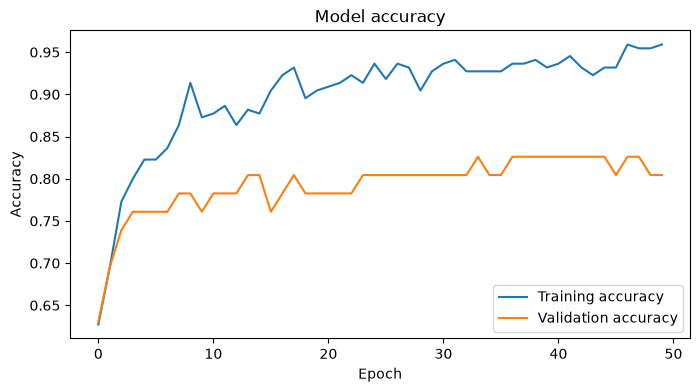

In [57]:
# This draws a chart of how the model improved during training.
# Two lines: how well it did on the teaching photos vs. the check photos.
# If both lines climb and stay close, that's a healthy sign of good learning.

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Training accuracy")       # score on teaching photos
plt.plot(history.history["val_accuracy"], label="Validation accuracy") # score on check photos
plt.title("Model accuracy")
plt.xlabel("Epoch")    # each study session, left to right
plt.ylabel("Accuracy") # how often it guessed right (higher is better)
plt.legend()           # show which line is which
plt.show()

## 9. Test on images the model has not seen

The test set was held back from training. This gives us a more honest score.

In [58]:
# Time for the final exam! We test the model on photos it has never seen before.
# This is the fairest way to know how well it really learned.

if TEST_DIR.exists():
    # Load the exam photos (we keep their order fixed, no shuffling needed here).
    test_ds = keras.utils.image_dataset_from_directory(
        TEST_DIR,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=False,
    )
    # Grade the model on these photos and print the score as a percentage.
    test_loss, test_acc = model.evaluate(test_ds)
    print(f"Test accuracy: {test_acc:.1%}")
else:
    print("No test folder found. Skipping test evaluation.")

Found 50 files belonging to 2 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9400 - loss: 0.1837
Test accuracy: 94.0%


## 10. Load a saved model instead of training

If training is too slow in Binder, you can load another model Tadhg trained just for you ❤️:

`models/crop_classifier_mobilenetv2.keras`

Run this cell to load it.

In [ ]:
# This cell loads a model we saved earlier, so you can come back another day
# and use it without training all over again. Handy if you restart the notebook.

if MODEL_PATH.exists():
    model = keras.models.load_model(MODEL_PATH)   # reopen the saved "brain"
    print("Loaded saved model:", MODEL_PATH)
else:
    print("No saved model found yet. Train the model first or add a saved model file.")

# Also reload the saved list of crop names that goes with the model.
if CLASS_NAMES_PATH.exists():
    with open(CLASS_NAMES_PATH, "r") as f:
        class_names = json.load(f)
    print("Class names:", class_names)

## 11. Prediction helper

This function loads one image, prepares it the same way as training images, and asks the model for a prediction.

In [60]:
# This creates a reusable helper named "predict_image". A function is like a
# recipe: once written, you can use it over and over by giving it a photo.
# It takes one photo, asks the model what crop it is, and shows the answer.

def predict_image(image_path):
    """Look at one photo and guess which crop it shows.

    Give it the location of a photo, and it will display the photo with the
    model's best guess and how confident it is (as a percentage).
    """
    image_path = Path(image_path)   # make sure the file location is in the right form

    # Open the photo and shrink it to the size the model expects.
    img = keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = keras.utils.img_to_array(img)   # turn the photo into numbers
    batch = np.expand_dims(img_array, axis=0)   # wrap it as a batch of one (the model expects batches)

    # Ask the model for its guess. The answer is a number between 0 and 1.
    probability = float(model.predict(batch, verbose=0)[0][0])

    # The model gives a 0-to-1 score. Closer to 1 means the second crop,
    # closer to 0 means the first crop. 0.5 is the dividing line.
    predicted_index = 1 if probability >= 0.5 else 0
    # Confidence is how sure the model is about its pick.
    confidence = probability if predicted_index == 1 else 1 - probability
    predicted_label = class_names[predicted_index]   # turn that into the crop's name

    # Show the photo with the guess and confidence written on top.
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.1%}")
    plt.show()

    # Hand back the details in case we want to use them elsewhere.
    return {
        "image": str(image_path),
        "predicted_label": predicted_label,
        "confidence": confidence,
        "raw_probability_class_1": probability,
    }

## 12. Upload a field photo and classify it

Use this after students take photos at the farm.

Upload one image, then click the button to classify it.

In [61]:
# This builds a simple point-and-click tool right inside the notebook so you can
# upload your own crop photo and let the model guess. No coding needed to use it!

import ipywidgets as widgets                      # tools for buttons and upload boxes
from IPython.display import display, clear_output # tools to show them on screen

# An "upload" box where you can choose an image file from your device.
upload = widgets.FileUpload(
    accept="image/*",   # only allow image files
    multiple=False,     # one photo at a time
)

# A green button you click to run the prediction.
button = widgets.Button(
    description="Classify uploaded image",
    button_style="success",
)

output = widgets.Output()   # a spot on screen where the result will appear


def get_uploaded_file(upload_widget):
    """Take the photo you uploaded and save it to a folder, then return its location."""
    # If nothing was uploaded yet, there's nothing to do.
    if not upload_widget.value:
        return None

    value = upload_widget.value

    # Different versions of the upload tool hand us the file in slightly different
    # shapes, so we check for both and pull out the file name and its contents.
    if isinstance(value, dict):
        # Older version format.
        first_key = next(iter(value))
        item = value[first_key]
        name = first_key
        content = item["content"]
    else:
        # Newer version format.
        item = value[0]
        name = item["name"]
        content = item["content"]

    # Save the uploaded photo into a folder so we can open it like any other file.
    upload_dir = Path("uploaded_field_photos")
    upload_dir.mkdir(exist_ok=True)
    out_path = upload_dir / name
    out_path.write_bytes(content)
    return out_path


def on_button_clicked(_):
    """This runs every time you click the button."""
    with output:               # send anything we print into the output area
        clear_output()         # wipe the previous result first
        image_path = get_uploaded_file(upload)  # grab the uploaded photo
        if image_path is None:
            print("Upload an image first.")     # gentle reminder if none was chosen
            return
        predict_image(image_path)  # run our prediction helper on the photo


button.on_click(on_button_clicked)   # connect the button to the action above

display(upload, button, output)      # show the upload box, button, and result area

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='Classify uploaded image', style=ButtonStyle())

Output()

## Reflection questions

1. Did the model get the field photo right?
2. What part of the plant do you think the model noticed?
3. What could confuse the model?
4. Would the model still work if the crop was younger, older, wet, blurry, or partly hidden?
5. How could we improve the training data?